# Synthetic Ground-Truth Validation of Event-Aware c-GC

*Estimator variant: c-GC (conditional Granger).*


This notebook validates the rising-flank causal-Granger (**c-GC**) method described in
`3_meth.tex` (*Methodology &rarr; Validation and falsification protocol*) on **synthetic
data with a known directed network**, so that recovery can be measured against ground
truth before any biological interpretation.

The estimator is the supplied core **`GcStar`**, loaded directly from
`src/core/causalised-GC.py` (the same import path used by the `c-GC-star_*` notebooks),
**not** the `CausalisedGC` adapter.

The synthetic transients use a **motoneuron-like calcium waveform**: a finite,
multi-frame *sloped* rise followed by exponential decay (a double-exponential kernel
convolved with the event train), rather than an instantaneous one-frame jump. The
&asymp;&nbsp;7-frame rise is calibrated to the supplied **smoothed** (Case-D / `f_smooth`)
motoneuron traces, whose median rise span measures 6&ndash;9 frames across the eight supplied
fish/trials. **This multi-frame flank is produced largely by the 5-frame smoothing the
pipeline applies:** the underlying *corrected* dF/F rises in &asymp;&nbsp;1 frame, and events
propagate with a 1-frame latent delay (`PROP_DELAY`, now tunable), so the rising flank the
estimator exploits is &asymp;&nbsp;7&times; the latent precedence &mdash; a caveat for
orientation accuracy and subsampling, examined in Sections 6 and 8.

**Mapping to the manuscript hypotheses**

- **H1 &mdash; kinetic asymmetry:** multi-frame onset rise vs. prolonged decay; per-ROI
  $\gamma_i$, rise duration, SNR (`characterize_transients`).
- **H2 &mdash; rise-primary recovery:** directed-edge recovery of $X^{\mathrm{rise}}$ vs.
  $X^{\mathrm{full}}$, $X^{\mathrm{deconv}}$, $X^{\mathrm{fall}}$ (Eqs. rise/fall).
- **H3 / negative comparators:** falling-segment, cyclic-shift, and reverse-time nulls.
- **H4 &mdash; robustness:** decay-constant, SNR, and frame-rate (subsampling) sweeps with a
  frozen calibration / locked-evaluation seed split.
- **$W_{\mathrm{IC}}$ / $\Delta W_{\mathrm{IC}}$:** ipsilateral-consistency of recovered
  rise vs. fall structures.

> **Scope.** The executable pair-selection path documented in *Current implementation of
> rising-flank c-GC* compresses event frames into pseudo-time. Here each representation is
> fed to `GcStar` on the **full time axis**, so this notebook validates the *representation
> choice and estimator behaviour under known ground truth*, not the pseudo-time
> compression. Recovery is scored with the package's `edge_recovery` (which ignores
> self-loops); `GcStar`'s own `compute_metrics` assumes a transposed truth convention and
> is not used here.

<!-- reviewer-resume-contract -->
## Execution and resume contract

This notebook is aligned with the reviewer-revision implementation. Expensive work is checkpointed and safe to restart with the same configuration. Do not change methods, seeds, thresholds, or output paths while resuming. Saved outputs remain provisional until the compute-machine run and verification gates complete.


In [1]:
# --- Method & run scale (publication-grade) ---
# Set explicitly (not setdefault) so a plain top-to-bottom run reproduces the proper
# results regardless of any leftover shell environment overrides.
import os
os.environ["RF_METHOD"]       = "cgc"     # this notebook runs c-GC (conditional Granger)
os.environ["RF_N_PERM"]       = "1000"    # circular-shift surrogates
os.environ["RF_N_SEEDS"]      = "20"      # synthetic recordings per condition
os.environ["RF_N_STEPS"]      = "3000"    # frames per recording (apples-to-apples across both methods)
os.environ["RF_N_RUNS_OUTER"] = "10"      # independent random networks for error bars / CIs

In [2]:
# --- Setup: locate the repository and load GcStar directly from causalised-GC.py ---
from pathlib import Path
import hashlib, importlib.util, os, pickle, sys, time

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError as exc:  # pragma: no cover
    raise ImportError("Install pandas in this kernel before running the notebook.") from exc

try:
    from IPython.display import display
except Exception:  # pragma: no cover
    display = print

CORE_REL = Path("src/core/causalised-GC.py")
PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / CORE_REL).exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from the repository or its notebooks/ directory.")

SRC, CORE = PROJECT_ROOT / "src", PROJECT_ROOT / "src" / "core"
for p in (SRC, CORE):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Load the supplied c-GC / c-GC* core exactly as the c-GC-star_* notebooks do.
spec = importlib.util.spec_from_file_location("causalised_gc", PROJECT_ROOT / CORE_REL)
causalised_gc = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = causalised_gc
spec.loader.exec_module(causalised_gc)
GcStar = causalised_gc.GcStar

# Pure (non-estimator) helpers from the package: events, representations, metrics, plots.
from calcium_transient_rising_flank import (
    build_representations,
    characterize_transients,
    edge_recovery,
    graph_summary,
    plot_directed_graph,
    plot_matrix,
    positions_from_mid,
    sides_from_mid,
)
from calcium_transient_rising_flank.checkpointing import atomic_write_pickle, format_progress, load_pickle
from calcium_transient_rising_flank.validation import (
    cyclic_shift_surrogate,
    generate_static_validation_network,
    simulate_static_calcium_like,
    static_calcium_kernel,
    static_gamma_from_tau,
    static_input_digest,
)

SEED = 0
np.random.seed(SEED)
print("Project root:", PROJECT_ROOT)
print("Loaded GcStar from", PROJECT_ROOT / CORE_REL)


Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank
Loaded GcStar from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/src/core/causalised-GC.py


## Configuration and the motoneuron-like simulator

Defaults are sized to run on the pure-Python core in a few minutes. Override from the
shell for publication-grade runs, e.g. `RF_N_PERM=1000 RF_N_SEEDS=20 RF_N_STEPS=1500`.

Set `TAU` (or `RF_TAU`) to keep only one causal lag after fitting; leave it as `None`
to preserve the existing merged-`N_LAGS` behavior. `N_PASTS` is the conditioning-history
depth and must be at least `TAU` when a fixed lag is selected.

The waveform is a double-exponential kernel $k(t)=(1-e^{-t/\tau_r})\,e^{-t/\tau_d}$
convolved with the binary event train, giving a finite, sloped rise (time-to-peak
$\approx\tau_r\ln(1+\tau_d/\tau_r)$) and an exponential decay. `RF_RISE_TAU` /
`RF_DECAY_TAU` control the rise and decay scales in frames.


In [3]:
METHOD     = os.environ.get("RF_METHOD", "cgc")          # 'cgc' or 'cgc-star'
N_PERM     = int(os.environ.get("RF_N_PERM", "1000"))     # circular-shift permutations
N_PASTS    = int(os.environ.get("RF_N_PASTS", "2"))      # conditioning-history depth
N_LAGS     = int(os.environ.get("RF_N_LAGS", "1"))       # merged lag blocks when TAU is unset
TAU        = None  # set e.g. 2 to keep only lag-2 c-GC/c-GC* edges
TAU_OVERRIDE = os.environ.get("RF_TAU", "").strip().lower()
if TAU_OVERRIDE not in {"", "0", "none", "null"}:
    TAU = int(TAU_OVERRIDE)
ALPHA      = float(os.environ.get("RF_ALPHA", "0.01"))   # unconditional significance (Chen-style)
BETA       = float(os.environ.get("RF_BETA", "0.001"))   # conditional significance (Chen-style)
SIMULATION = os.environ.get("RF_SIMULATION", "1").lower() not in {"0", "false", "no"}
N_STEPS    = int(os.environ.get("RF_N_STEPS", "2000"))    # frames per recording
N_SEEDS    = int(os.environ.get("RF_N_SEEDS", "5"))      # synthetic recordings per condition
if TAU is not None:
    if TAU < 1:
        raise ValueError("TAU must be positive when provided.")
    if N_PASTS < TAU:
        raise ValueError("N_PASTS must be at least TAU so the selected lag exists.")

# Motoneuron-like waveform (frames). The ~7-frame rise matches the supplied *smoothed*
# (Case-D / f_smooth) motoneuron traces (measured median rise 6-9 frames across the eight
# supplied fish/trials). The underlying *corrected* dF/F rises in ~1 frame, so this
# multi-frame flank is produced largely by the SMOOTH_WIN moving average, not by indicator
# kinetics; events propagate with a latent PROP_DELAY (default 1 frame). The rising flank the
# estimator exploits is therefore ~7x the latent precedence -- a caveat for orientation and
# subsampling (see Sections 6 and 8).
RISE_TAU   = float(os.environ.get("RF_RISE_TAU", "5.0"))   # rise scale (frames; time-to-peak ~7)
DECAY_TAU  = float(os.environ.get("RF_DECAY_TAU", "14.0")) # decay scale (frames; ~3.5 s @ 4 Hz)
NOISE_STD  = float(os.environ.get("RF_NOISE_STD", "0.03")) # observation noise (peak = 1)
AMP_JITTER = float(os.environ.get("RF_AMP_JITTER", "0.3")) # per-event amplitude variation
SMOOTH_WIN = int(os.environ.get("RF_SMOOTH_WIN", "5"))     # moving-average smoothing (Case-D-like)
SPONT_RATE = float(os.environ.get("RF_SPONT_RATE", "0.012"))  # spontaneous event rate
TRANS_PROB = float(os.environ.get("RF_TRANS_PROB", "0.85"))   # propagation probability
TOLERANCE  = float(os.environ.get("RF_TOLERANCE", "0.05"))    # rise/fall increment tolerance (delta)
IPSI_FRACTION = float(os.environ.get("RF_IPSI_FRACTION", "0.65"))  # target within-side edge fraction
PROP_DELAY = int(os.environ.get("RF_PROP_DELAY", "1"))    # latent event propagation delay (frames)

METHOD_SLUG = "cgc" if METHOD == "cgc" else "cgc_star"
FIG_DIR = PROJECT_ROOT / "outputs" / "validation_figures" / METHOD_SLUG
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESUME = True
IMPLEMENTATION_REVISION = 'reviewer-2026-08-v2'
FIT_CHECKPOINT_DIR = PROJECT_ROOT / 'outputs' / 'notebook_checkpoints' / METHOD_SLUG / 'estimator_fits'


def notebook_log(status: str, message: str) -> None:
    print(f'[{METHOD_SLUG}] {status}: {message}', flush=True)


def notebook_progress(completed: int, total: int, *, label: str) -> None:
    notebook_log('PROGRESS', format_progress(completed, total, label=label))

def _fit_checkpoint_path(matrix, *, method, n_perm):
    values = np.ascontiguousarray(np.asarray(matrix, dtype=float))
    digest = hashlib.sha256()
    digest.update(values.view(np.uint8))
    digest.update(repr((IMPLEMENTATION_REVISION, values.shape, method, n_perm, N_PASTS, N_LAGS, TAU, ALPHA, BETA, SIMULATION)).encode())
    return FIT_CHECKPOINT_DIR / f'{digest.hexdigest()}.pkl'


def generate_random_network(n_roi: int, seed: int, ipsi_fraction: float = IPSI_FRACTION) -> tuple:
    """Generate a random directed network with a controlled *ipsilateral* bias.

    Approximately ``ipsi_fraction`` of edges fall within a side (left = nodes
    ``[0, mid)``, right = nodes ``[mid, n_roi)``); the remainder cross sides with a
    randomized direction. This makes the ground truth genuinely ipsilateral so that
    ``Delta W_IC`` has a known, non-trivial target (uniform-random edges, by contrast,
    have no ipsilateral structure and make the W_IC contrast ill-posed).

    Returns ``(adjacency, sides, positions, mid, true_w_ic)`` where ``true_w_ic`` is the
    ipsilateral-consistency statistic of the generated network itself.
    """
    adjacency, sides, positions, mid = generate_static_validation_network(
        n_roi, seed=seed, ipsilateral_fraction=ipsi_fraction
    )
    true_w_ic = graph_summary(adjacency, mid)["w_ic"]
    return adjacency, sides, positions, mid, true_w_ic


def calcium_kernel(rise_tau, decay_tau, length=None):
    """Double-exponential calcium response: finite sloped rise then exponential decay."""
    return static_calcium_kernel(rise_tau, decay_tau, length)


def gamma_from_tau(decay_tau):
    """Per-frame AR(1) decay implied by the decay scale (for the deconvolution comparator)."""
    return static_gamma_from_tau(decay_tau)


def simulate_calcium_like(adjacency, n_steps, rise_tau=RISE_TAU, decay_tau=DECAY_TAU,
                          noise_std=NOISE_STD, shared_noise_std=0.0, spontaneous_rate=SPONT_RATE,
                          transmission_probability=TRANS_PROB, amp_jitter=AMP_JITTER,
                          smooth_window=SMOOTH_WIN, propagation_delay=PROP_DELAY, random_state=None):
    """Motoneuron-like calcium observations with a known directed-event network.

    Events propagate on `adjacency` with a latent `propagation_delay` (frames); each event is
    convolved with `calcium_kernel` (a finite multi-frame rise + decay) and the noisy trace is
    lightly smoothed, as in the supplied smoothed (Case-D) motoneuron recordings, so rises span
    several frames with a real slope. The smoothing, not the latent kinetics, is the main source
    of the multi-frame rising flank (the corrected dF/F rises in ~1 frame).
    """
    return simulate_static_calcium_like(
        adjacency, n_steps, rise_tau=rise_tau, decay_tau=decay_tau,
        noise_std=noise_std, shared_noise_std=shared_noise_std,
        spontaneous_rate=spontaneous_rate,
        transmission_probability=transmission_probability,
        amplitude_jitter=amp_jitter, smooth_window=smooth_window,
        propagation_delay=propagation_delay, random_state=random_state,
    )


def _connectivity_at_tau(estimator, tau):
    """Return weighted [source, target] connectivity from one lag block."""
    n_neur = estimator.data.shape[0]
    start = tau * n_neur
    stop = (tau + 1) * n_neur
    sig_corr = np.multiply(
        estimator.corr_[start:stop, :n_neur],
        estimator.pVal_corr_[start:stop, :n_neur] <= ALPHA,
    )
    sig_inv = np.multiply(
        estimator.inv_corr_[start:stop, :n_neur],
        estimator.pVal_inv_corr_[start:stop, :n_neur] <= BETA,
    )
    inferred = np.logical_and(sig_corr, sig_inv)
    return np.multiply(estimator.corr_[:n_neur, :n_neur], inferred)


def fit_cgc(matrix, method=None, n_perm=None, *, context='fit'):
    """Fit GcStar with an atomic per-input checkpoint."""
    selected_method = METHOD if method is None else method
    selected_n_perm = N_PERM if n_perm is None else n_perm
    checkpoint = _fit_checkpoint_path(matrix, method=selected_method, n_perm=selected_n_perm)
    fit_label = f'{context} [{selected_method}, n_perm={selected_n_perm}]'
    if RESUME and checkpoint.is_file():
        notebook_log('CACHED', f'{fit_label} loaded from {checkpoint}')
        return np.asarray(load_pickle(checkpoint)['weighted'], dtype=float)
    notebook_log('START', f'{fit_label} -> {checkpoint}')
    estimator = GcStar(
        n_perm=selected_n_perm,
        n_pasts=N_PASTS, n_lags=N_LAGS, temporal=True,
        method=selected_method,
    )
    estimator.fit(np.asarray(matrix, dtype=float), verbose=0)
    if TAU is None:
        weighted = estimator.get_connectivity_matrix(
            simulation=SIMULATION,
            alpha=ALPHA,
            beta=BETA,
        )
    else:
        weighted = _connectivity_at_tau(estimator, TAU)
    weighted = np.nan_to_num(np.asarray(weighted, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(weighted, 0.0)
    atomic_write_pickle(checkpoint, {'weighted': weighted})
    notebook_log('DONE', f'{fit_label} saved to {checkpoint}')
    return weighted


def score_recovery(truth, weighted):
    """Directed-edge recovery against a known network (diagonal ignored)."""
    r = edge_recovery(truth, np.asarray(weighted) != 0.0)
    denom = r.precision + r.recall
    f1 = 2 * r.precision * r.recall / denom if denom else 0.0
    return {
        "precision": r.precision, "recall": r.recall, "fpr": r.false_positive_rate,
        "orientation": r.orientation_accuracy, "f1": f1,
        "tp": r.true_positives, "fp": r.false_positives, "fn": r.false_negatives,
    }


def paired_permutation_pvalue(diffs, n_perm=20000, random_state=0):
    """Two-sided paired sign-flip permutation test for mean(diffs) != 0.

    Dependency-free (numpy only), matching the project's permutation-based ethos. For
    n <= 20 paired observations the 2**n sign assignments are enumerated exactly;
    otherwise ``n_perm`` random sign flips are sampled. Returns (mean_diff, p_value).
    """
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    n = diffs.size
    if n == 0:
        return float("nan"), float("nan")
    observed = float(np.mean(diffs))
    if n <= 20:                                   # exact enumeration of all sign flips
        signs = np.array(np.meshgrid(*([[1, -1]] * n))).T.reshape(-1, n)
    else:
        signs = np.random.default_rng(random_state).choice([1, -1], size=(n_perm, n))
    null_means = (signs * diffs).mean(axis=1)
    pval = float(np.mean(np.abs(null_means) >= abs(observed) - 1e-12))
    return observed, pval


print(f"method={METHOD}; n_perm={N_PERM}; n_pasts={N_PASTS}; n_lags={N_LAGS}; "
      f"tau={TAU}; alpha={ALPHA}; beta={BETA}; simulation={SIMULATION}; "
      f"n_steps={N_STEPS}; n_seeds={N_SEEDS}")
print(f"waveform: rise_tau={RISE_TAU}, decay_tau={DECAY_TAU}, noise_std={NOISE_STD}, "
      f"smooth_win={SMOOTH_WIN}, spont_rate={SPONT_RATE}, tolerance={TOLERANCE}; "
      f"implied AR(1) gamma={gamma_from_tau(DECAY_TAU):.3f}; ipsi_fraction={IPSI_FRACTION}; "
      f"prop_delay={PROP_DELAY} (rise-to-peak ~{int(np.argmax(calcium_kernel(RISE_TAU, DECAY_TAU)))} frames)")


method=cgc; n_perm=1000; n_pasts=2; n_lags=1; tau=None; alpha=0.01; beta=0.001; simulation=True; n_steps=3000; n_seeds=20
waveform: rise_tau=5.0, decay_tau=14.0, noise_std=0.03, smooth_win=5, spont_rate=0.012, tolerance=0.05; implied AR(1) gamma=0.931; ipsi_fraction=0.65; prop_delay=1 (rise-to-peak ~7 frames)


## 1. Synthetic ground-truth network

A bilateral spinal-circuit motif motivated by the zebrafish application: two ipsilateral,
rostrocaudal chains (left $0\to1\to2$, right $3\to4\to5$). It is fully ipsilateral, so the
ground-truth $W_{\mathrm{IC}}=1$. Matrices are oriented `[source, target]`.


sides: ['L', 'L', 'L', 'R', 'R', 'R'] | positions: [0, 1, 2, 0, 1, 2]
ground-truth W_IC = 1.0


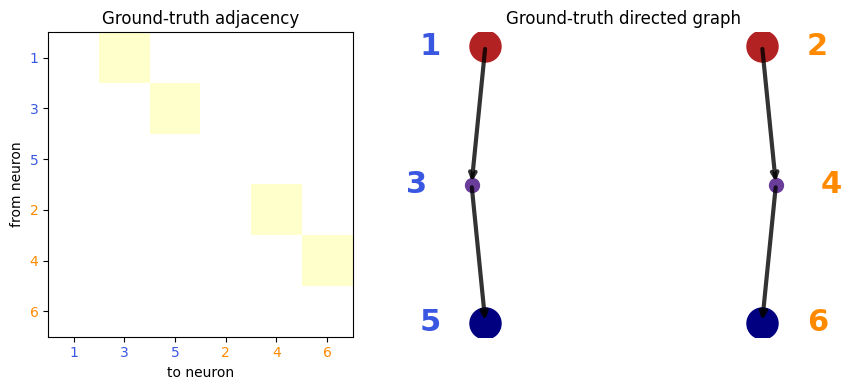

In [4]:
N_ROI, MID = 6, 3
EDGES = [(0, 1), (1, 2), (3, 4), (4, 5)]            # left chain (L) and right chain (R)
truth = np.zeros((N_ROI, N_ROI), dtype=float)
for a, b in EDGES:
    truth[a, b] = 1.0

sides = sides_from_mid(N_ROI, MID)                  # L L L R R R
positions = positions_from_mid(N_ROI, MID)          # 0 1 2 0 1 2
print("sides:", sides.tolist(), "| positions:", positions.astype(int).tolist())
print("ground-truth W_IC =", graph_summary(truth, MID)["w_ic"])

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
plot_matrix(truth, MID, ax=ax[0]); ax[0].set_title("Ground-truth adjacency")
plot_directed_graph(truth, MID, ax=ax[1]); ax[1].set_title("Ground-truth directed graph")
fig.tight_layout()
fig.savefig(FIG_DIR / "ground_truth.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Motoneuron-like calcium waveform

The response kernel and a single isolated transient. The rise spans several frames with a
real slope (multiple consecutive rising-flank frames), matching the supplied **smoothed**
(Case-D / `f_smooth`) motoneuron recordings (median rise &asymp; 7 frames). In the
*unsmoothed* corrected dF/F the latent rise is &asymp; 1 frame; the multi-frame flank here is
produced mainly by the 5-frame smoothing step, reproducing the regime the deployed pipeline
actually analyses rather than the raw indicator kinetics.

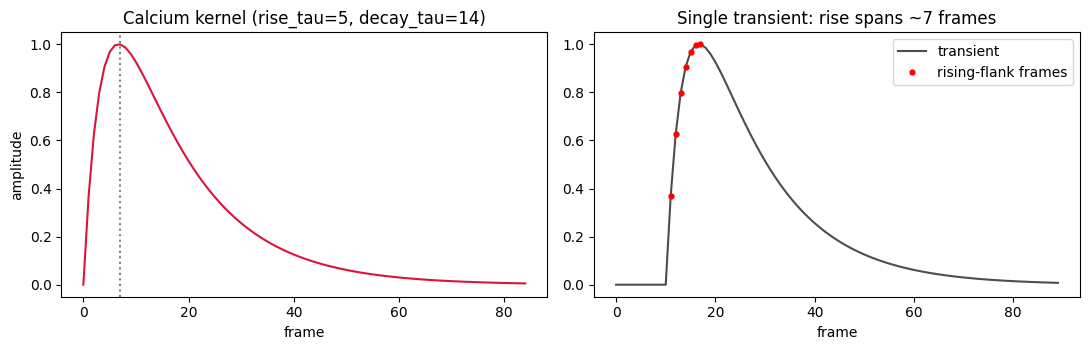

time-to-peak (rise length) = 7 frames; rising-flank frames per transient = 7


In [5]:
kernel = calcium_kernel(RISE_TAU, DECAY_TAU)
rise_len = int(np.argmax(kernel))                    # frames from onset to peak
single = np.zeros(90); single[10] = 1.0
single_resp = np.convolve(single, kernel)[:90]
rising = np.flatnonzero(np.diff(single_resp) > 0) + 1

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(kernel, color="crimson"); ax[0].axvline(rise_len, ls=":", color="0.5")
ax[0].set_title(f"Calcium kernel (rise_tau={RISE_TAU:g}, decay_tau={DECAY_TAU:g})")
ax[0].set_xlabel("frame"); ax[0].set_ylabel("amplitude")
ax[1].plot(single_resp, color="0.3", label="transient")
ax[1].plot(rising, single_resp[rising], "r.", ms=7, label="rising-flank frames")
ax[1].set_title(f"Single transient: rise spans ~{rise_len} frames")
ax[1].set_xlabel("frame"); ax[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "waveform.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"time-to-peak (rise length) = {rise_len} frames; rising-flank frames per transient = {rising.size}")

## 3. Observation model and H1 (kinetic asymmetry)

The known events drive the motoneuron-like waveform. Before any graph inspection we
characterise transients per ROI: fitted decay persistence $\widehat{\gamma}_i$, rise count
and duration, event density, and robust SNR. The median rise duration should now be
several frames, not one.


,gamma_hat,event_density,rise_count,median_rise_dur,SNR
ROI,,,,,
0,0.954,0.080,36,7.0,5.698
1,0.954,0.128,57,7.0,4.283
2,0.954,0.159,69,7.0,3.106
3,0.955,0.091,41,7.0,5.394
4,0.956,0.154,70,6.0,3.287
5,0.955,0.188,88,6.0,2.621


mean median-rise-duration across ROIs = 6.7 frames


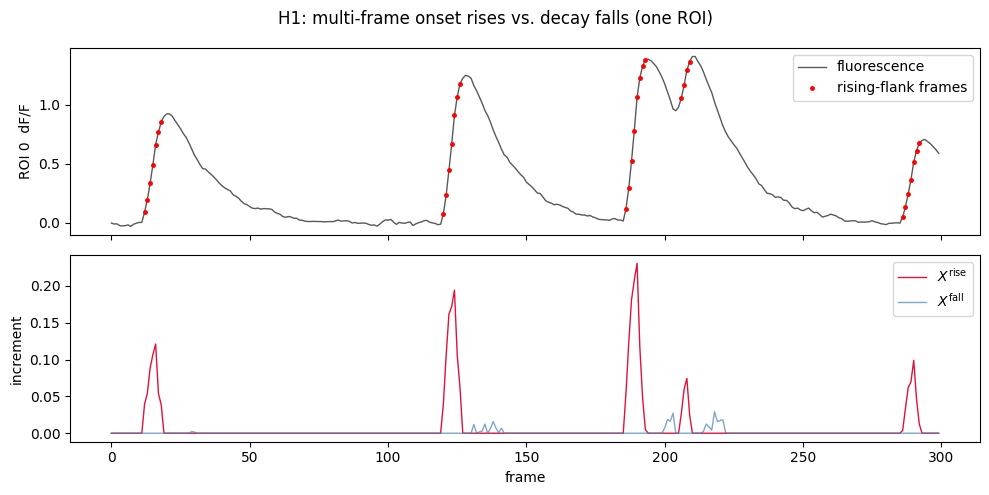

In [6]:
data = simulate_calcium_like(truth, n_steps=N_STEPS, random_state=SEED)
reps = build_representations(data.fluorescence, tolerance=TOLERANCE, gamma=gamma_from_tau(DECAY_TAU))

ts = characterize_transients(data.fluorescence, tolerance=TOLERANCE)
h1 = pd.DataFrame({
    "gamma_hat": ts.gamma, "event_density": ts.event_density, "rise_count": ts.rise_count,
    "median_rise_dur": ts.median_rise_duration, "SNR": ts.signal_to_noise,
})
h1.index.name = "ROI"
display(h1.round(3))
print(f"mean median-rise-duration across ROIs = {np.mean(ts.median_rise_duration):.1f} frames")

roi, stop = 0, min(300, N_STEPS)
t = np.arange(stop)
rise_frames = np.flatnonzero(reps.rise[roi] > 0)
rise_frames = rise_frames[rise_frames < stop]
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, data.fluorescence[roi, :stop], color="0.35", lw=1, label="fluorescence")
ax[0].plot(rise_frames, data.fluorescence[roi, rise_frames], "r.", ms=5, label="rising-flank frames")
ax[0].set_ylabel(f"ROI {roi}  dF/F"); ax[0].legend(loc="upper right")
ax[1].plot(t, reps.rise[roi, :stop], color="crimson", lw=1, label=r"$X^{\mathrm{rise}}$")
ax[1].plot(t, reps.fall[roi, :stop], color="steelblue", lw=1, alpha=0.7, label=r"$X^{\mathrm{fall}}$")
ax[1].set_ylabel("increment"); ax[1].set_xlabel("frame"); ax[1].legend(loc="upper right")
fig.suptitle("H1: multi-frame onset rises vs. decay falls (one ROI)")
fig.tight_layout()
fig.savefig(FIG_DIR / "h1_transient.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. H2: rise-primary recovery on one dataset

Each representation is fed to `GcStar` on the full time axis and scored against the known
network. The rising representation is expected to recover the directed chains at least as
well as the full, deconvolved, and falling comparators.


,precision,recall,fpr,f1,orientation,W_IC
representation,,,,,,
full,0.667,1.00,0.077,0.800,0.667,1.0
deconvolved,0.800,1.00,0.038,0.889,0.800,1.0
rise,0.800,1.00,0.038,0.889,1.000,1.0
fall,0.600,0.75,0.077,0.667,0.600,1.0


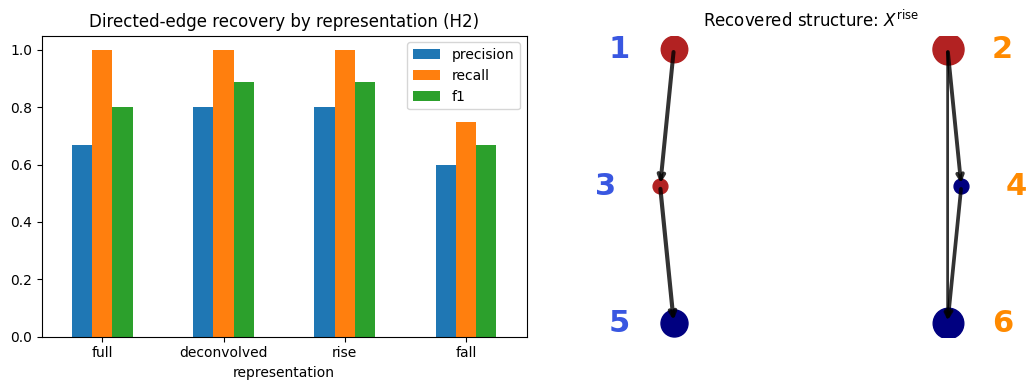

In [7]:
representations = {
    "full": reps.full, "deconvolved": reps.deconvolved, "rise": reps.rise, "fall": reps.fall,
}
rows, rep_graphs = [], {}
notebook_log('START', f'H2 representation comparison across {len(representations)} inputs')
for index, (name, mat) in enumerate(representations.items(), start=1):
    W = fit_cgc(mat, context=f'H2 representation={name}')
    rep_graphs[name] = W
    rows.append({"representation": name, **score_recovery(truth, W),
                 "W_IC": graph_summary(W, MID)["w_ic"]})
    notebook_progress(index, len(representations), label='H2 representation fits')
rep_df = pd.DataFrame(rows).set_index("representation")
display(rep_df[["precision", "recall", "fpr", "f1", "orientation", "W_IC"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
rep_df[["precision", "recall", "f1"]].plot.bar(ax=ax[0])
ax[0].set_title("Directed-edge recovery by representation (H2)")
ax[0].set_ylim(0, 1.05); ax[0].tick_params(axis="x", rotation=0)
plot_directed_graph(rep_graphs["rise"], MID, ax=ax[1])
ax[1].set_title(r"Recovered structure: $X^{\mathrm{rise}}$")
fig.tight_layout()
fig.savefig(FIG_DIR / "h2_representations.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Calibration vs. locked evaluation across conditions

Recovery is evaluated across declared observation regimes (decay, noise, frame rate,
shared hidden input) and several seeds. Seeds are split once into a calibration set and a
frozen locked-evaluation set; aggregate recovery is reported on the locked set only.


In [8]:
CONDITIONS = {
    "native":        dict(rise_tau=RISE_TAU, decay_tau=DECAY_TAU,     noise_std=NOISE_STD, shared_noise_std=0.00, downsample=1),
    "noisy":         dict(rise_tau=RISE_TAU, decay_tau=DECAY_TAU,     noise_std=0.08,      shared_noise_std=0.00, downsample=1),
    "slow_decay":    dict(rise_tau=RISE_TAU, decay_tau=2 * DECAY_TAU, noise_std=NOISE_STD, shared_noise_std=0.00, downsample=1),
    "low_framerate": dict(rise_tau=RISE_TAU, decay_tau=DECAY_TAU,     noise_std=NOISE_STD, shared_noise_std=0.00, downsample=2),
    "shared_input":  dict(rise_tau=RISE_TAU, decay_tau=DECAY_TAU,     noise_std=NOISE_STD, shared_noise_std=0.10, downsample=1),
}
GRID_REPS = ["rise", "fall"]
N_RUNS = int(os.environ.get("RF_N_RUNS_OUTER", "10"))  # number of independent runs for error bars / CIs

run_results = []
input_manifest_rows = []
run_times = []
t_total_start = time.time()

print(f"\n{'='*70}")
print(f"SECTION 5: Grid Analysis ({N_RUNS} runs × {len(CONDITIONS)} conditions)")
print(f"{'='*70}\n")

TOTAL_GRID_FITS = N_RUNS * len(CONDITIONS) * N_SEEDS * len(GRID_REPS)
completed_grid_fits = 0
notebook_log('START', f'Section 5 scheduled for {TOTAL_GRID_FITS} representation fits')

for run_idx in range(N_RUNS):
    t_run_start = time.time()
    
    # Generate ipsilaterally-biased random network for this run
    n_roi = int(np.random.RandomState(SEED + run_idx * 10).uniform(6, 13))
    truth, sides, positions, MID, true_wic = generate_random_network(n_roi, seed=SEED + run_idx * 10)
    true_edges = int(truth.sum())
    
    seed_offset = run_idx * (N_SEEDS + 100)
    seeds = list(range(seed_offset + 1, seed_offset + N_SEEDS + 1))
    
    records, t0 = [], time.time()
    for cname, cfg in CONDITIONS.items():
        ds = cfg["downsample"]
        for sd in seeds:
            d = simulate_calcium_like(
                truth, n_steps=N_STEPS, rise_tau=cfg["rise_tau"], decay_tau=cfg["decay_tau"],
                noise_std=cfg["noise_std"], shared_noise_std=cfg["shared_noise_std"],
                random_state=sd,
            )
            fluo = d.fluorescence[:, ::ds] if ds > 1 else d.fluorescence
            input_manifest_rows.append({
                "run": run_idx, "condition": cname, "seed": sd,
                "n_rois": fluo.shape[0], "n_timepoints": fluo.shape[1],
                "input_digest": static_input_digest(truth, fluo),
                "input_contract": "static-cgc-grid-v1",
            })
            r = build_representations(fluo, tolerance=TOLERANCE, gamma=gamma_from_tau(cfg["decay_tau"]) ** ds)
            rmap = {"rise": r.rise, "fall": r.fall}
            for rep in GRID_REPS:
                W = fit_cgc(rmap[rep], context=f'Section 5 run={run_idx + 1}/{N_RUNS} condition={cname} seed={sd} rep={rep}')
                completed_grid_fits += 1
                notebook_progress(completed_grid_fits, TOTAL_GRID_FITS, label='Section 5 fits')
                records.append({"condition": cname, "seed": sd, "representation": rep,
                                "W_IC": graph_summary(W, MID)["w_ic"], "true_W_IC": true_wic,
                                **score_recovery(truth, W)})
    grid_df = pd.DataFrame(records)
    
    rng = np.random.default_rng(SEED + run_idx)
    perm = rng.permutation(seeds)
    k = max(1, len(seeds) // 2)
    cal_seeds = {int(x) for x in perm[:k]}
    eval_seeds = {int(x) for x in perm[k:]}
    for manifest_row in input_manifest_rows:
        if manifest_row["run"] == run_idx:
            manifest_row["split"] = (
                "calibration" if manifest_row["seed"] in cal_seeds else "evaluation"
            )
    grid_df["split"] = np.where(grid_df.seed.isin(cal_seeds), "calibration", "evaluation")
    
    locked = grid_df[grid_df.split == "evaluation"]
    pivot = locked.pivot_table(index="condition", columns="representation", values="recall", aggfunc="mean")
    for cond in pivot.index:
        for rep in pivot.columns:
            run_results.append({"run": run_idx, "condition": cond, "representation": rep, 
                               "recall": pivot.loc[cond, rep], "n_roi": n_roi, "n_edges": true_edges,
                               "true_wic": true_wic})
    
    t_run = time.time() - t_run_start
    run_times.append(t_run)
    
    # Calculate ETA
    avg_time = np.mean(run_times)
    remaining_runs = N_RUNS - run_idx - 1
    eta_sec = remaining_runs * avg_time
    eta_min = eta_sec / 60
    
    print(f"  Run time: {t_run:.1f}s | Avg: {avg_time:.1f}s | ETA: {eta_min:.1f}m ({int(eta_sec)}s)", flush=True)
    print(f"  Network: {n_roi} ROIs, {true_edges} edges, true W_IC={true_wic:.2f} | {len(grid_df)} grid fits", flush=True)
    print(flush=True)

t_total = time.time() - t_total_start
print(f"{'='*70}")
print(f"Section 5 complete: {t_total:.1f}s total ({t_total/60:.1f}m)")
print(f"Average per run: {np.mean(run_times):.1f}s")
print(f"{'='*70}\n")

run_df = pd.DataFrame(run_results)
pivot_mean = run_df.pivot_table(index="condition", columns="representation", values="recall", aggfunc="mean")
# Reindex std to the mean's shape: pivot_table drops all-NaN columns, which happens when
# a single run leaves std undefined; reindex keeps rise/fall present (filled with NaN).
pivot_std = (run_df.pivot_table(index="condition", columns="representation", values="recall", aggfunc="std")
             .reindex(index=pivot_mean.index, columns=pivot_mean.columns))
display(pivot_mean.round(3))
display(pivot_std.round(3))

# Paired rise-vs-fall recall test per condition (sign-flip permutation across independent runs).
# .xs() always returns a DataFrame (rows=run, cols=representation), robust for any N_RUNS.
paired = run_df.pivot_table(index=["condition", "run"], columns="representation", values="recall")
test_rows = []
for cond in pivot_mean.index:
    sub = paired.xs(cond, level="condition")
    if {"rise", "fall"} <= set(sub.columns):
        d = (sub["rise"] - sub["fall"]).to_numpy()
    else:
        d = np.array([], dtype=float)
    obs, p = paired_permutation_pvalue(d, random_state=SEED)
    test_rows.append({"condition": cond, "mean_rise_minus_fall": obs,
                      "n_runs": int(np.sum(~np.isnan(d))), "p_value": p})
paired_test_df = pd.DataFrame(test_rows).set_index("condition")
print("Paired rise - fall recall (two-sided sign-flip permutation test across runs):")
display(paired_test_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pivot_mean.index))
width = 0.35
for i, rep in enumerate(pivot_mean.columns):
    yerr = pivot_std[rep].to_numpy(dtype=float)
    yerr = np.where(np.isfinite(yerr), yerr, 0.0)   # std undefined for a single run -> no error bar
    ax.bar(x + i * width, pivot_mean[rep], width, label=rep, yerr=yerr, capsize=4)
ax.set_xlabel("condition"); ax.set_ylabel("recall (locked eval)"); ax.set_ylim(0, 1.05)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(pivot_mean.index, rotation=20)
ax.set_title(f"H2/H4: rise vs. fall recall across conditions (N_RUNS={N_RUNS}, ipsilateral networks)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "h4_conditions.png", dpi=150, bbox_inches="tight")
plt.show()


SECTION 5: Grid Analysis (10 runs × 5 conditions)



KeyboardInterrupt: 

## 6. Null and negative-comparator checks

Cyclic-shift surrogates disrupt between-ROI temporal order; reverse-time is an additional
warning check; the falling-segment representation is a structural negative comparator.

The **primary** null statistic is **recall of the true oriented edges** against a
self-contained bilateral ground-truth chain, not the raw retained-edge count: reversing
time on a chain $0\to1\to2$ produces its mirror image $2\to1\to0$ — the *same* number of
edges with the *wrong* orientation — so an edge-count null cannot distinguish signal from
its time-reversed copy. Oriented recall must collapse under a valid null even when edges
remain. Retained-edge counts are still shown alongside for continuity.

In [ ]:
N_NULL = int(os.environ.get("RF_N_NULL", "6"))

# Self-contained known network so this check does not depend on the grid loop above
# (which leaves `truth`/`reps` pointing at the last random network). A bilateral chain
# is used so the *oriented* recovery has an unambiguous target.
NULL_TRUTH_EDGES = [(0, 1), (1, 2), (3, 4), (4, 5)]
null_truth = np.zeros((6, 6), dtype=float)
for a, b in NULL_TRUTH_EDGES:
    null_truth[a, b] = 1.0
null_data = simulate_calcium_like(null_truth, n_steps=N_STEPS, random_state=SEED)
null_reps = build_representations(null_data.fluorescence, tolerance=TOLERANCE, gamma=gamma_from_tau(DECAY_TAU))
rise = null_reps.rise
true_edges = int(null_truth.sum())

# Fit the observed rise and each null/negative comparator.
TOTAL_H3_FITS = N_NULL + 3
completed_h3_fits = 0
notebook_log('START', f'H3 scheduled for {TOTAL_H3_FITS} observed/null/comparator fits')
W_obs = fit_cgc(rise, context='H3 observed rise')
completed_h3_fits += 1
notebook_progress(completed_h3_fits, TOTAL_H3_FITS, label='H3 fits')
W_shift = []
for j in range(N_NULL):
    W_shift.append(
        fit_cgc(
            cyclic_shift_surrogate(rise, random_state=1000 + j, minimum_shift=N_PASTS + 1),
            context=f'H3 cyclic-shift null {j + 1}/{N_NULL}',
        )
    )
    completed_h3_fits += 1
    notebook_progress(completed_h3_fits, TOTAL_H3_FITS, label='H3 fits')
W_rev = fit_cgc(rise[:, ::-1], context='H3 reverse-time comparator')
completed_h3_fits += 1
notebook_progress(completed_h3_fits, TOTAL_H3_FITS, label='H3 fits')
W_fall = fit_cgc(null_reps.fall, context='H3 falling-flank comparator')
completed_h3_fits += 1
notebook_progress(completed_h3_fits, TOTAL_H3_FITS, label='H3 fits')

# PRIMARY null statistic: recall of the TRUE ORIENTED edges. Raw edge count cannot tell a
# real chain 0->1->2 from its time-reversed image 2->1->0 (same count, wrong orientation);
# oriented recall must collapse under a valid null even when edges remain.
obs_recall = score_recovery(null_truth, W_obs)["recall"]
null_recall = [score_recovery(null_truth, W)["recall"] for W in W_shift]
rev_score = score_recovery(null_truth, W_rev)
fall_recall = score_recovery(null_truth, W_fall)["recall"]

# SECONDARY (context): raw retained-edge counts, kept for continuity with earlier reports.
obs_edges = int((W_obs != 0).sum())
null_edges = [int((W != 0).sum()) for W in W_shift]
rev_edges = int((W_rev != 0).sum())
fall_edges = int((W_fall != 0).sum())

print(f"observed rise: oriented recall={obs_recall:.2f}, edges={obs_edges} (truth has {true_edges})")
print(f"cyclic-shift null: recall mean={np.mean(null_recall):.2f} "
      f"(range {min(null_recall):.2f}-{max(null_recall):.2f}); edges mean={np.mean(null_edges):.1f}")
print(f"reverse-time: recall={rev_score['recall']:.2f}, orientation={rev_score['orientation']:.2f}, "
      f"edges={rev_edges} | falling comparator: recall={fall_recall:.2f}, edges={fall_edges}")

names = ["observed\n(rise)"] + [f"null{j + 1}" for j in range(N_NULL)] + ["reverse\ntime", "fall"]
colors = ["crimson"] + ["0.7"] * N_NULL + ["steelblue", "darkorange"]
recall_vals = [obs_recall] + null_recall + [rev_score["recall"], fall_recall]
edge_vals = [obs_edges] + null_edges + [rev_edges, fall_edges]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(names, recall_vals, color=colors)
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("recall of true oriented edges")
ax[0].set_title("Nulls scored by oriented recall (primary)")
ax[1].bar(names, edge_vals, color=colors)
ax[1].axhline(true_edges, ls="--", color="k", lw=1, label="true #edges")
ax[1].set_ylabel("retained edges"); ax[1].set_title("Retained-edge counts (context)"); ax[1].legend()
for a in ax:
    a.tick_params(axis="x", rotation=0)
fig.suptitle("Null & negative-comparator checks (rise)")
fig.tight_layout()
fig.savefig(FIG_DIR / "h3_nulls.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Ipsilateral consistency and $\Delta W_{\mathrm{IC}}$

Using the grid above, the paired rise-minus-fall ipsilateral-consistency contrast
$\Delta W_{\mathrm{IC}} = W_{\mathrm{IC}}^{\mathrm{rise}} - W_{\mathrm{IC}}^{\mathrm{fall}}$
is summarised per condition. The grid networks are now generated with a controlled
ipsilateral bias (`IPSI_FRACTION`), so each has a known, non-trivial ground-truth
$W_{\mathrm{IC}}$ (printed below). Recovered **rise** structures should track that
ipsilateral target more faithfully than **fall**, giving $\Delta W_{\mathrm{IC}} > 0$.

In [ ]:
wide = grid_df.pivot_table(index=["condition", "seed"], columns="representation", values="W_IC")
wide = wide.dropna(subset=["rise", "fall"], how="any").copy()
wide["delta_W_IC"] = wide["rise"] - wide["fall"]
display(wide.groupby(level="condition")[["rise", "fall", "delta_W_IC"]].mean().round(3))
print(f"ground-truth W_IC of the (ipsilaterally-biased) last-run network = {true_wic:.3f} "
      f"-- recovered rise W_IC should sit nearer this target than fall.")

present = [c for c in CONDITIONS if c in wide.index.get_level_values(0)]
box_data = [np.asarray(wide.loc[c, "delta_W_IC"]).ravel() for c in present]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot(box_data)
ax[0].set_xticks(range(1, len(present) + 1)); ax[0].set_xticklabels(present, rotation=20)
ax[0].axhline(0, ls="--", color="k", lw=1)
ax[0].set_ylabel(r"$\Delta W_{\mathrm{IC}}$ (rise - fall)")
ax[0].set_title("Paired ipsilateral-consistency contrast")
ax[1].scatter(wide["fall"], wide["rise"], c="crimson", s=18)
lims = [0, 1.02]; ax[1].plot(lims, lims, "k--", lw=1); ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].axhline(true_wic, ls=":", color="green", lw=1, alpha=0.8, label=r"ground-truth $W_{IC}$")
ax[1].axvline(true_wic, ls=":", color="green", lw=1, alpha=0.8)
ax[1].set_xlabel(r"fall $W_{\mathrm{IC}}$"); ax[1].set_ylabel(r"rise $W_{\mathrm{IC}}$")
ax[1].set_title("rise vs. fall $W_{IC}$ (per run)"); ax[1].legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "wic_delta.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Robustness sweeps (SNR and frame rate)

Single-axis sweeps of the rising representation: increasing observation noise and
decreasing the effective frame rate (subsampling). Subsampling is expected to erode
recall, consistent with the GC-detectability caveat in the methodology.


In [ ]:
sweep_results = []
sweep_times = []
t_total_start = time.time()

print(f"\n{'='*70}")
print(f"SECTION 8: Robustness Sweeps ({N_RUNS} runs × 7 parameter values)")
print(f"{'='*70}\n")

TOTAL_SWEEP_FITS = N_RUNS * min(3, N_SEEDS) * 7
completed_sweep_fits = 0
notebook_log('START', f'Section 8 scheduled for {TOTAL_SWEEP_FITS} rise fits')

for run_idx in range(N_RUNS):
    t_run_start = time.time()
    
    # Generate ipsilaterally-biased random network for this run (same as Section 5)
    n_roi = int(np.random.RandomState(SEED + run_idx * 10).uniform(6, 13))
    truth, sides, positions, MID, true_wic = generate_random_network(n_roi, seed=SEED + run_idx * 10)
    true_edges = int(truth.sum())
    
    seed_offset = run_idx * (N_SEEDS + 100)
    SWEEP_SEEDS = list(range(seed_offset + 1, seed_offset + min(3, N_SEEDS) + 1))
    
    noise_rows = []
    for nz in [0.03, 0.06, 0.12, 0.24]:
        for sd in SWEEP_SEEDS:
            d = simulate_calcium_like(truth, n_steps=N_STEPS, noise_std=nz, random_state=sd)
            r = build_representations(d.fluorescence, tolerance=TOLERANCE, gamma=gamma_from_tau(DECAY_TAU))
            noise_rows.append({
                "noise_std": nz,
                **score_recovery(
                    truth,
                    fit_cgc(r.rise, context=f'Section 8 noise run={run_idx + 1}/{N_RUNS} noise={nz} seed={sd}'),
                ),
            })
            completed_sweep_fits += 1
            notebook_progress(completed_sweep_fits, TOTAL_SWEEP_FITS, label='Section 8 rise fits')
    noise_df_raw = pd.DataFrame(noise_rows)
    noise_df = noise_df_raw.groupby("noise_std")[["precision", "recall", "fpr"]].mean()
    
    for nz in [0.03, 0.06, 0.12, 0.24]:
        for metric in ["precision", "recall"]:
            sweep_results.append({"run": run_idx, "sweep_type": "noise", "param": nz, 
                                 "metric": metric, "value": noise_df.loc[nz, metric], 
                                 "n_roi": n_roi, "n_edges": true_edges})
    
    frame_rows = []
    for fct in [1, 2, 3]:
        for sd in SWEEP_SEEDS:
            d = simulate_calcium_like(truth, n_steps=N_STEPS, random_state=sd)
            fluo = d.fluorescence[:, ::fct] if fct > 1 else d.fluorescence
            r = build_representations(fluo, tolerance=TOLERANCE, gamma=gamma_from_tau(DECAY_TAU) ** fct)
            frame_rows.append({
                "downsample": fct,
                **score_recovery(
                    truth,
                    fit_cgc(r.rise, context=f'Section 8 frame run={run_idx + 1}/{N_RUNS} downsample={fct} seed={sd}'),
                ),
            })
            completed_sweep_fits += 1
            notebook_progress(completed_sweep_fits, TOTAL_SWEEP_FITS, label='Section 8 rise fits')
    frame_df_raw = pd.DataFrame(frame_rows)
    frame_df = frame_df_raw.groupby("downsample")[["precision", "recall", "fpr"]].mean()
    
    for fct in [1, 2, 3]:
        for metric in ["precision", "recall"]:
            sweep_results.append({"run": run_idx, "sweep_type": "frame", "param": fct, 
                                 "metric": metric, "value": frame_df.loc[fct, metric],
                                 "n_roi": n_roi, "n_edges": true_edges})
    
    t_run = time.time() - t_run_start
    sweep_times.append(t_run)
    
    # Calculate ETA
    avg_time = np.mean(sweep_times)
    remaining_runs = N_RUNS - run_idx - 1
    eta_sec = remaining_runs * avg_time
    eta_min = eta_sec / 60
    
    print(f"  Run time: {t_run:.1f}s | Avg: {avg_time:.1f}s | ETA: {eta_min:.1f}m ({int(eta_sec)}s)", flush=True)
    print(f"  Network: {n_roi} ROIs, {true_edges} edges", flush=True)
    print(flush=True)

t_total = time.time() - t_total_start
print(f"{'='*70}")
print(f"Section 8 complete: {t_total:.1f}s total ({t_total/60:.1f}m)")
print(f"Average per run: {np.mean(sweep_times):.1f}s")
print(f"{'='*70}\n")

sweep_df = pd.DataFrame(sweep_results)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

noise_sweep = sweep_df[sweep_df.sweep_type == "noise"]
for metric in ["recall", "precision"]:
    metric_data = noise_sweep[noise_sweep.metric == metric]
    means = metric_data.groupby("param")["value"].mean()
    stds = metric_data.groupby("param")["value"].std()
    ax[0].errorbar(means.index, means, yerr=stds, marker="o" if metric == "recall" else "s", 
                  label=metric, capsize=4)
ax[0].set_title("Robustness to noise (rise)"); ax[0].set_ylim(0, 1.05)
ax[0].set_xlabel("noise_std"); ax[0].legend()

frame_sweep = sweep_df[sweep_df.sweep_type == "frame"]
for metric in ["recall", "precision"]:
    metric_data = frame_sweep[frame_sweep.metric == metric]
    means = metric_data.groupby("param")["value"].mean()
    stds = metric_data.groupby("param")["value"].std()
    ax[1].errorbar(means.index, means, yerr=stds, marker="o" if metric == "recall" else "s", 
                  label=metric, capsize=4)
ax[1].set_title("Robustness to subsampling (rise)"); ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("downsample factor"); ax[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "h4_sweeps.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Hypothesis | Test in this notebook | Section |
| --- | --- | --- |
| H1 kinetic asymmetry | per-ROI $\gamma_i$, rise duration, SNR | 2, 3 |
| H2 rise-primary recovery | edge recovery: rise vs. full / deconv / fall | 4, 5 |
| H3 / negative comparators | falling-segment, cyclic-shift, reverse-time nulls | 6 |
| $\Delta W_{\mathrm{IC}}$ | paired rise-minus-fall ipsilateral consistency | 7 |
| H4 robustness | noise and frame-rate sweeps; locked-eval split | 5, 8 |

**Waveform.** Transients use a motoneuron-like double-exponential kernel (`RF_RISE_TAU`,
`RF_DECAY_TAU`) so the rising flank spans several frames with a real slope. The
&asymp;&nbsp;7-frame rise matches the supplied **smoothed** (Case-D / `f_smooth`) motoneuron
traces (measured median 6&ndash;9 frames); the underlying *corrected* dF/F rises in
&asymp;&nbsp;1 frame, so the multi-frame flank is produced mainly by the 5-frame smoothing,
not by indicator kinetics.

**Reproducibility.** All randomness is seeded (`SEED` and per-run `random_state`). Scale up
for reporting with environment overrides, e.g. `RF_N_PERM=1000 RF_N_SEEDS=20 RF_N_STEPS=2000`.
Figures are written to `outputs/validation_figures/`.

**Caveats.**
- Recovery is scored against a *known* network: this validates method behaviour under the
  stated generative model, not anatomical synapses.
- The latent event-propagation delay is 1 frame (`PROP_DELAY`, tunable via `RF_PROP_DELAY`)
  while the smoothed rise spans &asymp; 7 frames, so the rising flank is &asymp; 7&times; the
  causal precedence. This rise-to-delay ratio &mdash; not noise &mdash; is what bounds
  orientation accuracy and drives the recall collapse under subsampling (Section 8).
- Representations are fed to `GcStar` on the full time axis. The executable pair-selection
  path (*Current implementation of rising-flank c-GC*) compresses event frames into
  pseudo-time; quantifying that effect needs the masked/segmented follow-up noted there.
- `GcStar.get_connectivity_matrix(simulation=True)` returns `[source, target]` weights;
  recovery is scored with `edge_recovery` (self-loops ignored), since the core's own
  `compute_metrics` assumes a transposed truth convention and counts the diagonal.

## Saved artifacts

This final cell persists everything needed to (re)compile the manuscript results
section without re-reading the notebook: all numeric tables as CSV, a consolidated
`summary.json`, and the two figures referenced by `4_results.tex` copied into the
repository `figures/` directory (`val_waveform.png`, `val_robustness.png`).

In [ ]:
# --- Persist every artifact needed to compile the results section ---
import json, shutil

RESULTS_DIR = PROJECT_ROOT / "outputs" / "validation_results" / METHOD_SLUG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MANUSCRIPT_FIG_DIR = PROJECT_ROOT.parent / "figures"
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1) Numeric tables as CSV
h1.to_csv(RESULTS_DIR / "h1_transient_characterization.csv")
rep_df.to_csv(RESULTS_DIR / "representation_recovery.csv")
grid_df.to_csv(RESULTS_DIR / "grid_runs.csv", index=False)
pd.DataFrame(input_manifest_rows).to_csv(RESULTS_DIR / "input_manifest.csv", index=False)
paired_test_df.to_csv(RESULTS_DIR / "paired_rise_vs_fall_test.csv")
locked_by_rep = locked.groupby("representation")[["precision", "recall", "fpr", "W_IC"]].mean()
locked_by_rep.to_csv(RESULTS_DIR / "locked_recovery_by_representation.csv")
pivot.to_csv(RESULTS_DIR / "locked_recall_by_condition.csv")
wic_by_cond = wide.groupby(level="condition")[["rise", "fall", "delta_W_IC"]].mean()
wic_by_cond.to_csv(RESULTS_DIR / "wic_delta_by_condition.csv")
noise_df.to_csv(RESULTS_DIR / "robustness_noise.csv")
frame_df.to_csv(RESULTS_DIR / "robustness_framerate.csv")

# 2) Consolidated scalar summary as JSON (config + headline numbers + null metrics)
summary = {
    "config": {k: globals()[k] for k in [
        "METHOD", "METHOD_SLUG", "N_PERM", "N_PASTS", "N_LAGS", "TAU", "ALPHA", "BETA", "SIMULATION",
        "N_STEPS", "N_SEEDS", "RISE_TAU", "DECAY_TAU", "NOISE_STD", "SMOOTH_WIN",
        "SPONT_RATE", "TRANS_PROB", "TOLERANCE", "IPSI_FRACTION", "PROP_DELAY"]},
    "n_runs_outer": int(N_RUNS),
    "calibration_seeds": sorted(int(s) for s in cal_seeds),
    "evaluation_seeds": sorted(int(s) for s in eval_seeds),
    "rise_length_frames": int(rise_len),
    "median_rise_duration_mean_frames": float(np.mean(ts.median_rise_duration)),
    "gamma_hat_mean": float(np.mean(ts.gamma)),
    "representative_recovery": rep_df[["precision", "recall", "fpr", "f1", "W_IC"]].round(4).to_dict("index"),
    "locked_recovery": locked_by_rep.round(4).to_dict("index"),
    "paired_rise_vs_fall": paired_test_df.round(4).to_dict("index"),
    "wic_delta_by_condition": wic_by_cond.round(4).to_dict("index"),
    "nulls": {
        # primary: recall of true ORIENTED edges (collapses under valid nulls)
        "observed_rise_oriented_recall": float(obs_recall),
        "cyclic_shift_mean_recall": float(np.mean(null_recall)),
        "cyclic_shift_max_recall": float(np.max(null_recall)),
        "reverse_time_recall": float(rev_score["recall"]),
        "reverse_time_orientation": float(rev_score["orientation"]),
        "falling_comparator_recall": float(fall_recall),
        # secondary: raw retained-edge counts (context only)
        "observed_rise_edges": int(obs_edges),
        "cyclic_shift_mean_edges": float(np.mean(null_edges)),
        "cyclic_shift_min_edges": int(min(null_edges)),
        "cyclic_shift_max_edges": int(max(null_edges)),
        "reverse_time_edges": int(rev_edges),
        "falling_comparator_edges": int(fall_edges),
        "true_edges": int(null_truth.sum()),  # the null check's own ground truth (not the grid leftover)
    },
}
(RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

# 3) Copy the figures referenced by 4_results.tex into the manuscript figures dir
for src_name, dst_name in [("waveform.png", f"val_waveform_{METHOD_SLUG}.png"),
                           ("h4_sweeps.png", f"val_robustness_{METHOD_SLUG}.png")]:
    shutil.copyfile(FIG_DIR / src_name, MANUSCRIPT_FIG_DIR / dst_name)
if METHOD_SLUG == "cgc":  # canonical names referenced by 4_results.tex
    shutil.copyfile(FIG_DIR / "waveform.png", MANUSCRIPT_FIG_DIR / "val_waveform.png")
    shutil.copyfile(FIG_DIR / "h4_sweeps.png", MANUSCRIPT_FIG_DIR / "val_robustness.png")

print("Saved tables + summary.json to", RESULTS_DIR)
print("Copied manuscript figures to", MANUSCRIPT_FIG_DIR)
print(json.dumps(summary, indent=2))